t=0.00  norm=1.0000
t=0.50  norm=1.0000
t=1.00  norm=1.0000
t=1.50  norm=1.0000
t=2.50  norm=1.0000
t=3.00  norm=1.0000
t=4.00  norm=1.0000


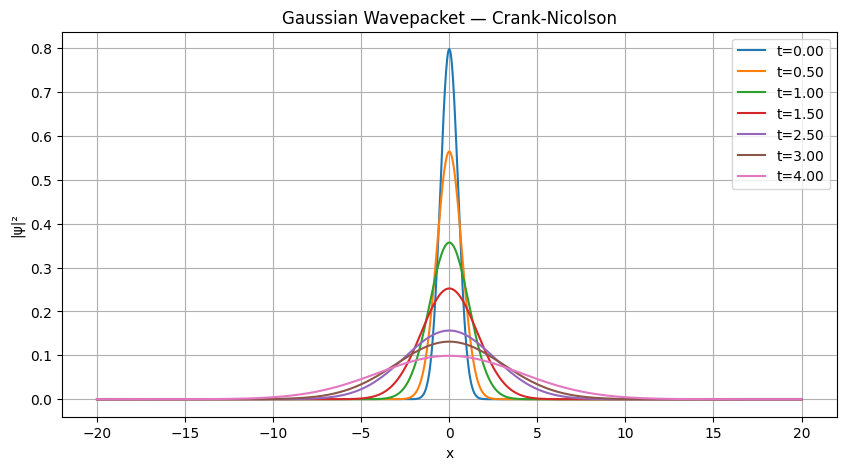

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def f(x):
    a = 1
    return ((2*a/np.pi)**(1/4)) * np.exp(-a*x**2)

def finite_diff_cn(x_p, nx, L):
    dx=2*L/(nx - 1)
    hbar_2m=0.5
    t=5
    dt=0.2*(dx**2)/hbar_2m
    nt = int(t / dt)
    r=1j *hbar_2m*dt/(2*dx**2)
    n=nx-2
    ab = np.zeros((3, n), dtype=complex)
    ab[0, 1:]  = -r              # upper diagonal
    ab[1, :]   = 1 + 2*r         # main diagonal
    ab[2, :-1] = -r              # lower diagonal
    u = np.zeros((nx, nt), dtype=complex)
    u[:, 0] = f(x_p)

    for l in range(nt - 1):
        # RHS
        rhs = r*u[:-2,l] + (1 - 2*r)*u[1:-1,l] + r*u[2:,l]
        u[1:-1, l+1] = solve_banded((1,1), ab, rhs)
        u[0,  l+1] = 0
        u[-1, l+1] = 0
    return u, nt, dt

L = 20
nx = 1200
x_p = np.linspace(-L, L, nx)
u_mat, nt, dt = finite_diff_cn(x_p, nx, L)

snapshots = [0.0, 0.5, 1.0, 1.5, 2.5,3,4]
plt.figure(figsize=(10,5))
for t_val in snapshots:


  time_idx = min(int(t_val / dt), nt - 1)
  prob_density = np.abs(u_mat[:, time_idx])**2
  norm = np.trapezoid(prob_density, x_p)
  print(f"t={t_val:.2f}  norm={norm:.4f}")
  plt.plot(x_p, prob_density, label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel("|ψ|²")
plt.title("Gaussian Wavepacket — Crank-Nicolson")
plt.legend()
plt.grid(True)
plt.show()

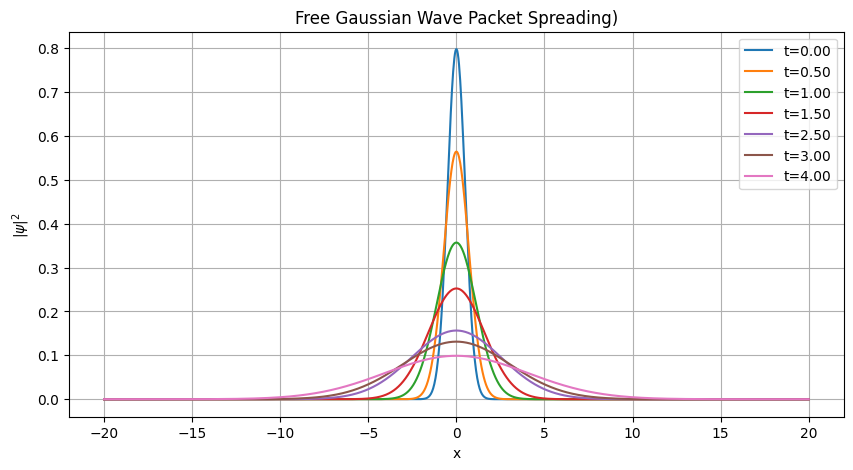

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def f(x):
    a = 1
    return ((2*a/np.pi)**(1/4)) * np.exp(-a*x**2)

def finite_diff_expcn(x_p, nx, L):
    dx=2*L/(nx - 1)
    hbar_2m=0.5
    t=5
    dt=0.2*(dx**2)/hbar_2m
    nt = int(t / dt)
    u=np.zeros((nx,nt))
    v=np.zeros((nx,nt))
    u[:,0]=f(x_p)
    v[:,0] = 0
    for l in range(nt-1):
      v[1:-1,l+1] = v[1:-1,l] + (hbar_2m*dt/dx**2)*(u[:-2,l]-2*u[1:-1,l]+u[2:,l])
      v[0,l+1]=v[1,l+1]+(hbar_2m * dt / dx**2) * (2 * u[1, l] - 2 * u[0, l])
      v[-1,l+1]=v[-2,l+1]+(hbar_2m * dt / dx**2) * (2 * u[-2, l] - 2 * u[-1, l])

      u[1:-1,l+1] = u[1:-1,l] - (hbar_2m*dt/dx**2)*(v[:-2,l+1]-2*v[1:-1,l+1]+v[2:,l+1])
      u[0,l+1]=u[1,l+1]-(hbar_2m * dt / dx**2) * (2 * v[1, l+1] - 2 * v[0, l+1])
      u[-1,l+1]=u[-2,l+1]- (hbar_2m * dt / dx**2) * (2 * v[-2, l+1] - 2 * v[-1, l+1])
    return u,v,nt,dt
L = 20
nx = 1200
x_p=np.linspace(-L, L, nx)

u_exp,v_exp, nt_exp, dt_exp =  finite_diff_expcn(x_p, nx, L)
prob_density=u_exp**2+v_exp**2
snapshots = [0.0, 0.5, 1.0, 1.5, 2.5, 3, 4]
plt.figure(figsize=(10,5))
for t_val in snapshots:
    time_idx = int(t_val / dt_exp)
    if time_idx >= nt_exp:
        time_idx = nt_exp - 1
        norm = np.trapezoid(prob_density, x_p)
        print(f"t={t_val:.2f}  norm={norm:.4f}")
    plt.plot(x_p, prob_density[:, time_idx], label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.grid(True)
plt.title("Free Gaussian Wave Packet Spreading)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def f(x):
    a = 1
    return ((2*a/np.pi)**(1/4)) * np.exp(-a*x**2)

def finite_diff_expcn(x_p, nx, L):
    dx=L/(nx - 1)
    hbar_2m=0.5
    t=5
    dt=0.2*(dx**2)/hbar_2m
    nt = int(t / dt)
    u=np.zeros((nx,nt))
    v=np.zeros((nx,nt))
    u[:,0]=f(x_p)
    v[:,0] = 0
    for l in range(nt-1):

        v[1:-1,l+1] = v[1:-1,l] + (hbar_2m*dt/dx**2)*(u[:-2,l]-2*u[1:-1,l]+u[2:,l])
        v[0,l+1]=v[1,l+1]; v[-1,l+1]=v[-2,l+1]

        u[1:-1,l+1] = u[1:-1,l] - (hbar_2m*dt/dx**2)*(v[:-2,l+1]-2*v[1:-1,l+1]+v[2:,l+1])
        u[0,l+1]=u[1,l+1]; u[-1,l+1]=u[-2,l+1]
    return u,v,nt,dt
L = 20
nx = 1200
x_p=np.linspace(-L, L, nx)

u_exp,v_exp, nt_exp, dt_exp =  finite_diff_expcn(x_p, nx, L)
prob_density=u_exp**2+v_exp**2
snapshots = [0.0, 0.5, 1.0, 1.5, 2.5, 3, 4]
plt.figure(figsize=(10,5))
for t_val in snapshots:
    time_idx = int(t_val / dt_exp)
    if time_idx >= nt_exp:
        time_idx = nt_exp - 1
      density_slice = prob_density[:, time_idx]
      norm = np.trapezoid(density_slice, x_p)
      print(f"t={t_val:.2f}  norm={norm:.4f}")
    plt.plot(x_p, prob_density[:, time_idx], label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.grid(True)
plt.title("Free Gaussian Wave Packet Spreading (Leapfrog FD)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def f(x):
    a = 1
    return ((2*a/np.pi)**(1/4)) * np.exp(-a*x**2)

def finite_diff_expcn(x_p, nx, L):
    dx=2*L/(nx - 1)
    hbar_2m=0.5
    t=5
    dt=0.2*(dx**2)/hbar_2m
    nt = int(t / dt)
    u=np.zeros((nx,nt))
    v=np.zeros((nx,nt))
    u[:,0]=f(x_p)
    v[:,0] = 0
    for l in range(nt-1):

        v[1:-1,l+1] = v[1:-1,l] + (hbar_2m*dt/dx**2)*(u[:-2,l]-2*u[1:-1,l]+u[2:,l])
        v[0,l+1]=v[1,l+1]; v[-1,l+1]=v[-2,l+1]

        u[1:-1,l+1] = u[1:-1,l] - (hbar_2m*dt/dx**2)*(v[:-2,l+1]-2*v[1:-1,l+1]+v[2:,l+1])
        u[0,l+1]=u[1,l+1]; u[-1,l+1]=u[-2,l+1]
    return u,v,nt,dt
L = 20
nx = 4200
x_p=np.linspace(-L, L, nx)

u_exp,v_exp, nt_exp, dt_exp =  finite_diff_expcn(x_p, nx, L)
prob_density=u_exp**2+v_exp**2
snapshots = [0.0, 0.5, 1.0, 1.5, 2.5, 3, 4]
plt.figure(figsize=(10,5))
for t_val in snapshots:
    time_idx = int(t_val / dt_exp)
    if time_idx >= nt_exp:
        time_idx = nt_exp - 1
    density_slice = prob_density[:, time_idx]
    norm = np.trapz(density_slice, x_p)
    print(f"t={t_val:.2f}  norm={norm:.4f}")
    plt.plot(x_p, prob_density[:, time_idx], label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.grid(True)
plt.title("Free Gaussian Wave Packet Spreading (Leapfrog FD)")
plt.legend()
plt.show()


NameError: name 'dt_exp' is not defined

<Figure size 1000x500 with 0 Axes>

In [5]:
!pip install -q deepxde

import os
os.environ["DDE_BACKEND"] = "pytorch"

import torch
print("GPU available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.9 MB/s eta 0:00:00
GPU available: False


In [6]:
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt

dde.config.set_random_seed(42)
dde.config.set_default_float("float32")

print("DeepXDE version:", dde.__version__)
print("Backend:", dde.backend.backend_name)

a = 1.0


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float32
DeepXDE version: 1.15.0
Backend: pytorch


Compiling model...
'compile' took 6.090930 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.89e-02, 4.21e-02, 3.37e-05, 1.92e-04, 1.58e+01, 1.46e+01]    [1.89e-02, 4.21e-02, 3.37e-05, 1.92e-04, 1.58e+01, 1.46e+01]    []  
1000      [5.71e-04, 3.94e-03, 9.58e-07, 1.58e-06, 2.73e-03, 1.98e-04]    [5.71e-04, 3.94e-03, 9.58e-07, 1.58e-06, 2.73e-03, 1.98e-04]    []  
2000      [4.01e-04, 2.46e-03, 1.16e-06, 6.45e-07, 9.28e-04, 3.76e-05]    [4.01e-04, 2.46e-03, 1.16e-06, 6.45e-07, 9.28e-04, 3.76e-05]    []  

Best model at step 2000:
  train loss: 3.83e-03
  test loss: 3.83e-03
  test metric: []

'train' took 885.798435 s

Compiling model...
'compile' took 0.000922 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
2000      [4.01e-04, 2.4

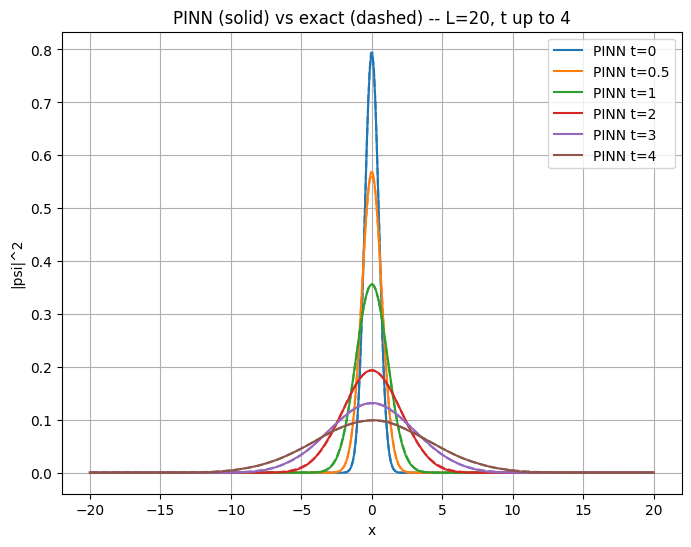

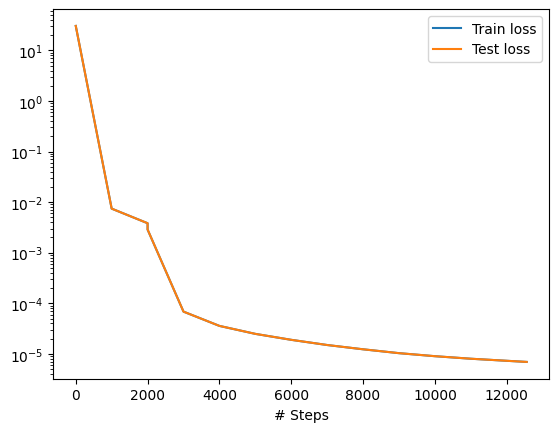

In [7]:
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt

a = 1.0

def pde(x, y):
    u_t  = dde.grad.jacobian(y, x, i=0, j=1)
    v_t  = dde.grad.jacobian(y, x, i=1, j=1)
    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    return [u_t + 0.5 * v_xx,
            v_t - 0.5 * u_xx]


geom = dde.geometry.Interval(-20, 20)
timedomain = dde.geometry.TimeDomain(0, 4)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

def psi0_real(x):
    return (2 * a / np.pi) ** 0.25 * np.exp(-a * x[:, 0:1] ** 2)

ic_u = dde.icbc.IC(geomtime, psi0_real, lambda _, on_initial: on_initial, component=0)
ic_v = dde.icbc.IC(geomtime, lambda x: np.zeros((len(x), 1)),
                   lambda _, on_initial: on_initial, component=1)

zero = lambda x: np.zeros((len(x), 1))
on_b = lambda x, on_boundary: on_boundary
bc_u = dde.icbc.NeumannBC(geomtime, zero, on_b, component=0)
bc_v = dde.icbc.NeumannBC(geomtime, zero, on_b, component=1)


data = dde.data.TimePDE(
    geomtime, pde, [bc_u, bc_v, ic_u, ic_v],
    num_domain=9000, num_boundary=600, num_initial=1200,
)

net = dde.nn.FNN([2] + [64] * 4 + [2], "tanh", "Glorot normal")

model = dde.Model(data, net)
model.compile("adam", lr=1e-3, loss_weights=[1, 1, 1, 1, 100, 100])
losshistory, train_state = model.train(iterations=2000)

model.compile("L-BFGS")
losshistory, train_state = model.train()

def exact_density(x, t):
    s = 1 + 4 * a**2 * t**2
    return np.sqrt(2 * a / np.pi) / np.sqrt(s) * np.exp(-2 * a * x**2 / s)


x = np.linspace(-20, 20, 400).reshape(-1, 1)
snapshots = [0, 0.5, 1, 2, 3, 4]

plt.figure(figsize=(8, 6))
for i, t in enumerate(snapshots):
    X = np.hstack([x, np.full_like(x, t)])
    y = model.predict(X)
    plt.plot(x, y[:, 0]**2 + y[:, 1]**2, color=f"C{i}", label=f"PINN t={t}")
    plt.plot(x, exact_density(x, t), "--", color=f"C{i}")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend(); plt.grid(True)
plt.title("PINN (solid) vs exact (dashed) -- L=20, t up to 4")
plt.show()

dde.utils.plot_loss_history(losshistory)

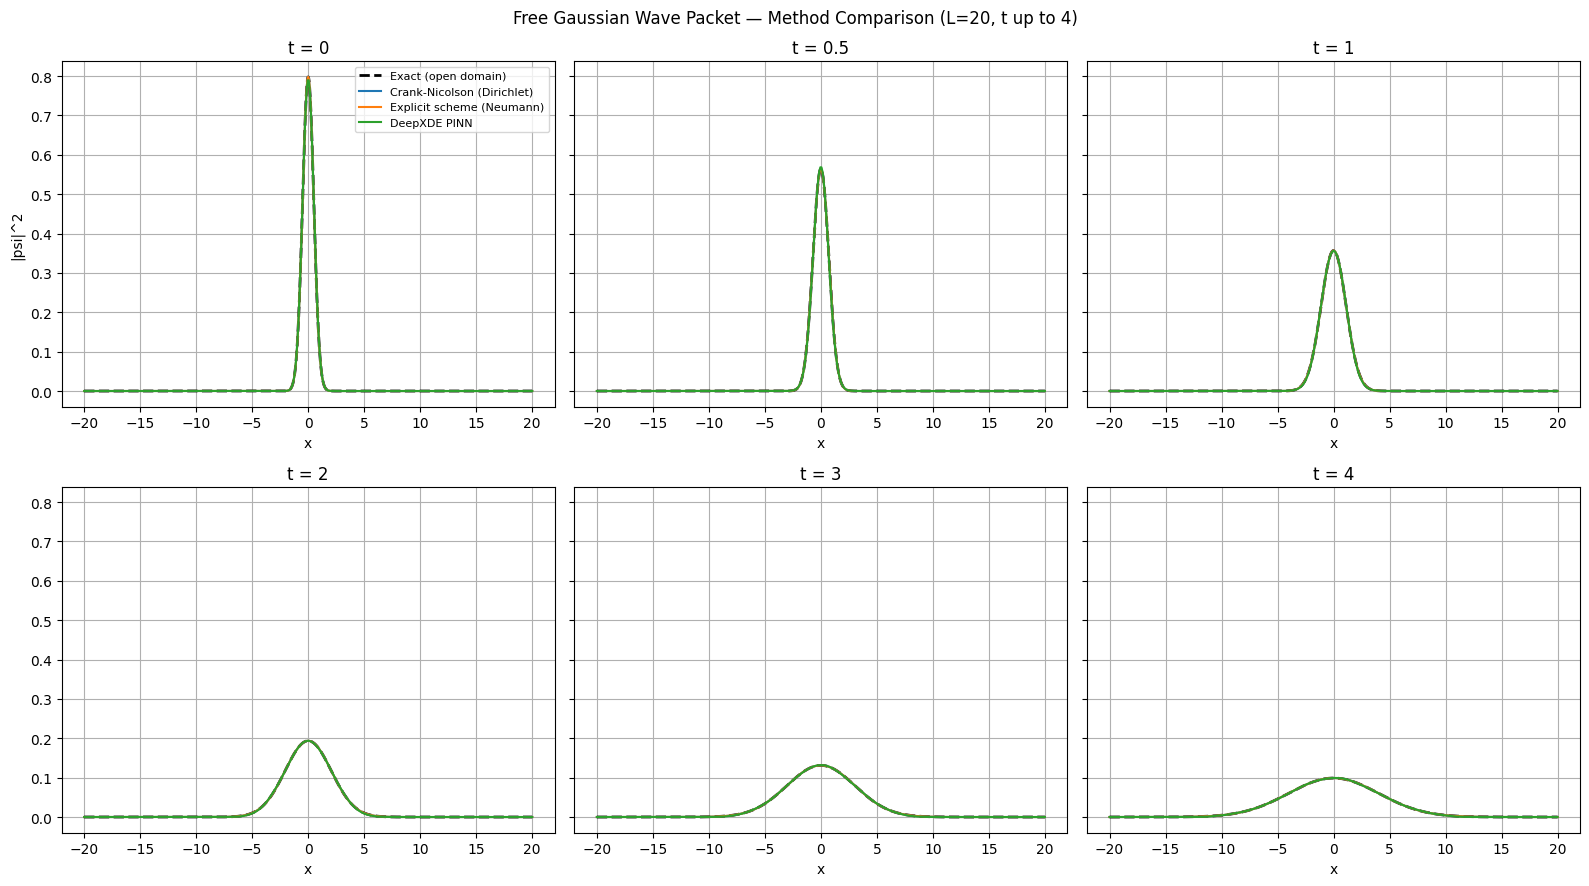

t=0.00  norm(CN)=1.0000  norm(explicit)=1.0000
t=0.50  norm(CN)=1.0000  norm(explicit)=0.9999
t=1.00  norm(CN)=1.0000  norm(explicit)=1.0000
t=2.00  norm(CN)=1.0000  norm(explicit)=1.0000
t=3.00  norm(CN)=1.0000  norm(explicit)=1.0000
t=4.00  norm(CN)=1.0000  norm(explicit)=1.0000


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

a = 1.0
L = 20.0
nx = 1200
T_PLOT = 4.0  # must match the DeepXDE timedomain above

def f_ic(x):
    return ((2*a/np.pi)**0.25) * np.exp(-a*x**2)

def finite_diff_cn(x_p, nx, L, t_run):
    dx = 2*L/(nx - 1)
    hbar_2m = 0.5
    dt = 0.2*(dx**2)/hbar_2m
    nt = int(t_run / dt)
    r = 1j * hbar_2m * dt / (2*dx**2)
    n = nx - 2
    ab = np.zeros((3, n), dtype=complex)
    ab[0, 1:]  = -r
    ab[1, :]   = 1 + 2*r
    ab[2, :-1] = -r
    u = np.zeros((nx, nt), dtype=complex)
    u[:, 0] = f_ic(x_p)
    for l in range(nt - 1):
        rhs = r*u[:-2, l] + (1 - 2*r)*u[1:-1, l] + r*u[2:, l]
        u[1:-1, l+1] = solve_banded((1, 1), ab, rhs)
        u[0,  l+1] = 0
        u[-1, l+1] = 0
    return u, nt, dt


def finite_diff_expcn(x_p, nx, L, t_run):
    dx = 2*L/(nx - 1)
    hbar_2m = 0.5
    dt = 0.2*(dx**2)/hbar_2m
    nt = int(t_run / dt)
    u = np.zeros((nx, nt))
    v = np.zeros((nx, nt))
    u[:, 0] = f_ic(x_p)
    v[:, 0] = 0
    for l in range(nt - 1):
        v[1:-1, l+1] = v[1:-1, l] + (hbar_2m*dt/dx**2)*(u[:-2, l]-2*u[1:-1, l]+u[2:, l])
        v[0,  l+1] = v[1,  l+1] + (hbar_2m*dt/dx**2)*(2*u[1, l]  - 2*u[0, l])
        v[-1, l+1] = v[-2, l+1] + (hbar_2m*dt/dx**2)*(2*u[-2, l] - 2*u[-1, l])

        u[1:-1, l+1] = u[1:-1, l] - (hbar_2m*dt/dx**2)*(v[:-2, l+1]-2*v[1:-1, l+1]+v[2:, l+1])
        u[0,  l+1] = u[1,  l+1] - (hbar_2m*dt/dx**2)*(2*v[1, l+1]  - 2*v[0, l+1])
        u[-1, l+1] = u[-2, l+1] - (hbar_2m*dt/dx**2)*(2*v[-2, l+1] - 2*v[-1, l+1])
    return u, v, nt, dt


def exact_density(x, t):
    s = 1 + 4*a**2*t**2
    return np.sqrt(2*a/np.pi) / np.sqrt(s) * np.exp(-2*a*x**2/s)

x_p = np.linspace(-L, L, nx)
u_cn, nt_cn, dt_cn = finite_diff_cn(x_p, nx, L, t_run=T_PLOT + 0.5)   # small buffer past last snapshot
u_exp, v_exp, nt_exp, dt_exp = finite_diff_expcn(x_p, nx, L, t_run=T_PLOT + 0.5)
prob_exp = u_exp**2 + v_exp**2


snapshots = [0, 0.5, 1, 2, 3, 4]
x_dde = np.linspace(-L, L, 400).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.ravel()

for i, t_val in enumerate(snapshots):
    ax = axes[i]

    # exact
    ax.plot(x_p, exact_density(x_p, t_val), 'k--', lw=2, label='Exact (open domain)')

    # Crank-Nicolson
    idx_cn = min(int(t_val/dt_cn), nt_cn-1)
    ax.plot(x_p, np.abs(u_cn[:, idx_cn])**2, label='Crank-Nicolson (Dirichlet)')

    # explicit scheme
    idx_exp = min(int(t_val/dt_exp), nt_exp-1)
    ax.plot(x_p, prob_exp[:, idx_exp], label='Explicit scheme (Neumann)')

    # DeepXDE PINN
    X = np.hstack([x_dde, np.full_like(x_dde, t_val)])
    y = model.predict(X)
    ax.plot(x_dde, y[:, 0]**2 + y[:, 1]**2, label='DeepXDE PINN')

    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x'); ax.grid(True)
    if i == 0:
        ax.set_ylabel('|psi|^2')

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Free Gaussian Wave Packet — Method Comparison (L=20, t up to 4)')
plt.tight_layout()
plt.show()


for t_val in snapshots:
    idx_cn = min(int(t_val/dt_cn), nt_cn-1)
    idx_exp = min(int(t_val/dt_exp), nt_exp-1)
    norm_cn = np.trapezoid(np.abs(u_cn[:, idx_cn])**2, x_p)
    norm_exp = np.trapezoid(prob_exp[:, idx_exp], x_p)
    print(f"t={t_val:.2f}  norm(CN)={norm_cn:.4f}  norm(explicit)={norm_exp:.4f}")

In [10]:
import numpy as np

def exact_density(x, t, a=1.0):
    s = 1 + 4*a**2*t**2
    return np.sqrt(2*a/np.pi)/np.sqrt(s) * np.exp(-2*a*x**2/s)

def rel_l2(num, exact):
    return np.linalg.norm(num - exact) / np.linalg.norm(exact)

In [11]:
for t_val in [0.5, 1, 2, 3, 4]:
    idx = min(int(t_val/dt), nt-1)
    num = np.abs(u_mat[:, idx])**2
    print(t_val, rel_l2(num, exact_density(x_p, t_val)))

0.5 0.0002896581778058352
1 0.0002968231516691616
2 0.00029889393039835054
3 0.00030386996009628846
4 0.0002595898171819686


In [12]:
for t_val in [0.5, 1, 2, 3, 4]:
    idx = min(int(t_val/dt_exp), nt_exp-1)
    num = u_exp[:, idx]**2 + v_exp[:, idx]**2
    print(t_val, rel_l2(num, exact_density(x_p, t_val)))

0.5 8.728166080308065e-05
1 0.00019752082507152127
2 0.00027424188785123247
3 0.0002922708015319851
4 0.0002633949950909834


In [13]:
x = np.linspace(-20, 20, 400).reshape(-1, 1)
for t_val in [0.5, 1, 2, 3, 4]:
    X = np.hstack([x, np.full_like(x, t_val)])
    y = model.predict(X)
    num = y[:, 0:1]**2 + y[:, 1:2]**2
    print(t_val, rel_l2(num, exact_density(x, t_val)))

0.5 0.00920364731179138
1 0.006750830028673803
2 0.007324561003194156
3 0.008621015439403223
4 0.009462999247643733


In [14]:
t_arr = np.arange(nt)*dt
exact_all = exact_density(x_p[:, None], t_arr[None, :])
num_all = np.abs(u_mat)**2
print(rel_l2(num_all[:, ::50], exact_all[:, ::50]))   # every 50th step to save memory

0.00022493243942302694
